# Incrementar volumetría de reseñas falsa

Tras el análisis detallado y la ejecución de los procesos descritos en el notebook  *02. categorizar_reviews_deep_seek*, hemos identificado una posible limitación en la capacidad del modelo para detectar eficazmente reseñas falsas. Esta dificultad podría atribuirse al desequilibrio existente en nuestro conjunto de datos actual, el cual presenta una cantidad considerablemente mayor de reseñas genuinas en comparación con el volumen de reseñas catalogadas como falsas. En consecuencia, y con el objetivo de mitigar este sesgo y potenciar la robustez del modelo, se ha tomado la decisión estratégica de obtener un nuevo subconjunto de reseñas de la plataforma Yelp. Para esta nueva extracción, nos enfocaremos en reseñas con una longitud específica comprendida entre 0 y 255 caracteres, buscando así optimizar el entrenamiento y la capacidad de detección del modelo.

Para realizar la extracción de las reseñas con logitudes comprendidas entre 0 y 512 caracteres, realizamos una ejecución adhoc de los notebook:
* [01. procesamiento_datos_yelp](<01. procesamiento_datos_yelp.ipynb>)
* [02. categorizar_reviews_deep_seek](<02. categorizar_reviews_deep_seek.ipynb>)

# Librerías

In [1]:
import polars as pl
import pandas as pd
import pyarrow
import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2') 
import seaborn as sns
import time
start_time_global = time.time()
import os
import sys
from dotenv import load_dotenv, find_dotenv 


color = '\033[1m\033[38;5;208m' 
print(f"{color}Versión pandas: {pd.__version__}")
print(f"{color}Versión polars: {pl.__version__}")
print(f"{color}Versión pyarrow: {pyarrow.__version__}")

Versión pandas: 2.2.3
Versión polars: 1.27.1
Versión pyarrow: 16.1.0


# Inicialización de las variables de entorno

In [2]:
#Cargar las variable de entorno
dotenv_path = find_dotenv()
carga_env = load_dotenv(dotenv_path=dotenv_path) 
if carga_env:
    print("Archivo .env encontrado y cargado exitosamente.")
else:
    print("No se encontró el archivo .env o no se pudo cargar.")

Archivo .env encontrado y cargado exitosamente.


In [3]:
#Directorio de trabajo
explicit_work_path = os.getenv('HOME_WORK')
# Agrega la carpeta fakereviews al syspath del proyecto
if explicit_work_path not in sys.path:
    sys.path.append(explicit_work_path)
from review_module import ReviewFinder

# Visualización de la evaluación de reseñas con longitudes de 0 a 255
A continuación, detallamos visualmente el resultado obtenido de la categorización realizada por DeepSeek.

In [85]:
# Lectura del fichero de las reseñas seleccionadas de yelp 0 a 255
review_categorice_0_255_file_path = f'{explicit_work_path}final_reviews_categorize_0_255.jsonl'
df_data_reviews_categorice_0_255_pl = pl.read_ndjson(review_categorice_0_255_file_path)
print(f"\nTotal de reseñas categorizadas: {df_data_reviews_categorice_0_255_pl.shape[0]}")


Total de reseñas categorizadas: 16999


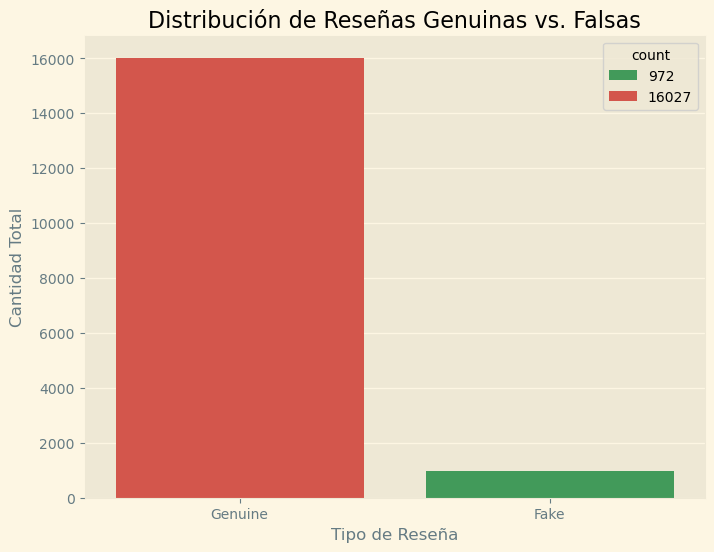

In [86]:
df_counts = df_data_reviews_categorice_0_255_pl['classification'].value_counts().to_pandas()

# Crear el gráfico de barras con Seaborn y Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='classification', y='count', data=df_counts, palette=['#34A853', '#EA4335'], hue='count') # Genuine (verde), Fake (rojo)

# Añadir títulos y etiquetas
plt.title('Distribución de Reseñas Genuinas vs. Falsas', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

## Conclusión

La gráfica anterior, titulada 'Distribución de Reseñas Genuinas vs. Falsas', ilustra la distribución final obtenida tras la categorización de las reseñas en Fake y Genuine del segmento de datos seleccionados con longitudes de 0 a 255 caracteres. En consonancia con lo explorado en el notebook [02. categorizar_reviews_deep_seek](<02. categorizar_reviews_deep_seek.ipynb>), esta visualización pone de manifiesto un desequilibrio de clases: se contabilizan 15864 reseñas 'Genuine' frente a únicamente 951 calificadas como 'Fake'. Este significativo desbalance numérico proporciona una base cuantitativa para la hipótesis de que la compañía Yelp podría estar aplicando un previo filtro de verificación y/o detección de reseñas falsas.

# Planteamiento de la selección y nivelación de las categorías

Dado que tenemos un conjunto de reseñas categorizado y con una distribución desequilibrada a la categoría 'Genuine', tomamos la decisión de equilibra la selección de datos, para ello seguimos los siguientes pasos:

1. Carga de los datos y unión de los dataset.
2. Agrupación y selección de datos por 'Categoría' y 'Clasificación'.
3. Introduciremos las reseñas y sus metadatos seleccionados en una base de datos vectorial, en nuestro caso usaremos Qdrant.
4. Seleccionaremos un nuevo conjunto de datos con el objetivo de incrementar la volumetría de reseñas falsas.

# 1. Carga de los datos y unión de los dataset.

In [27]:
# Lectura del fichero de las reseñas categorizadas de yelp de 255 a 512
review_categorice_file_path = f'{explicit_work_path}final_reviews_categorize.jsonl'
df_data_reviews_categorice_pl = pl.read_ndjson(review_categorice_file_path)
print(f"\nTotal de reseñas categorizadas con longitud de 256 a 512: {df_data_reviews_categorice_pl.shape[0]}")


Total de reseñas categorizadas con longitud de 256 a 512: 24259


In [28]:
# Lectura del fichero de las reseñas categorizadas de yelp 0 a 255
review_categorice_0_255_file_path = f'{explicit_work_path}final_reviews_categorize_0_255.jsonl'
df_data_reviews_categorice_0_255_pl = pl.read_ndjson(review_categorice_0_255_file_path)
print(f"\nTotal de reseñas categorizadas con longitud de 0 a 255: {df_data_reviews_categorice_0_255_pl.shape[0]}")


Total de reseñas categorizadas con longitud de 0 a 255: 16999


In [29]:
# Lectura del fichero de las reseñas seleccionadas de yelp de 256 a 512
review_selected_file_path = f'{explicit_work_path}yelp_academic_dataset_review_selected.jsonl'
df_data_reviews_selected_pl = pl.read_json(review_selected_file_path)
print(f"\nTotal de reseñas seleccionadas con longitud de 256 a 512: {df_data_reviews_selected_pl.shape[0]}")


Total de reseñas seleccionadas con longitud de 256 a 512: 17000


In [30]:
# Lectura del fichero de las reseñas seleccionadas de yelp de 0 a 255
review_selected_file_path = f'{explicit_work_path}yelp_academic_dataset_review_selected_0_255.jsonl'
df_data_reviews_selected_0_255_pl = pl.read_json(review_selected_file_path)
print(f"\nTotal de reseñas seleccionadas con longitud de 0 a 255: {df_data_reviews_selected_0_255_pl.shape[0]}")


Total de reseñas seleccionadas con longitud de 0 a 255: 16999


# 2. Agrupación y selección de datos por 'Categoría' y 'Clasificación'.

In [35]:
start_time=time.time()
try: 
    columns_target_classification = ['review_id','classification']
    columns_target_selected = ['review_id','user_id','business_id','text','stars','categories','review_count_business','stars_business', 
        'review_count_user','average_stars_user']
    df_final_fake_genuine_pl = pl.concat([
        df_data_reviews_categorice_pl.select(columns_target_classification),
        df_data_reviews_categorice_0_255_pl.select(columns_target_classification)
    ])
    df_final_selected_pl = pl.concat([
        df_data_reviews_selected_0_255_pl.select(columns_target_selected),
        df_data_reviews_selected_pl.select(columns_target_selected)
    ])
    df_final_pl = df_final_selected_pl.join(
        df_final_fake_genuine_pl,
        on='review_id', # La columna común para la unión
        how='left'
    ).select(
            [
                pl.col('review_id'),                
                pl.col('user_id'),
                pl.col('business_id'),
                pl.col('text'),
                pl.col('stars'),
                pl.col('categories'),
                pl.col('review_count_business'),
                pl.col('stars_business'),                
                pl.col('review_count_user'),
                pl.col('average_stars_user'),
                pl.col('classification')
            ]
        ).filter(pl.col('classification') != 'null')
except Exception as e:
    print(f"An error occurred: {e}")
else: 
    print(f"La operación fue exitosa en {time.time()-start_time:.2f}seg") 
    print("-" * 50 + "\n")
    print(f'Total reseñas: {len(df_final_pl)}')
    display(df_final_pl['classification'].value_counts())

La operación fue exitosa en 0.02seg
--------------------------------------------------

Total reseñas: 33951


classification,count
str,u32
"""Genuine""",32432
"""Fake""",1519


A continuación, veremos la distribución de la reseñas Genuine

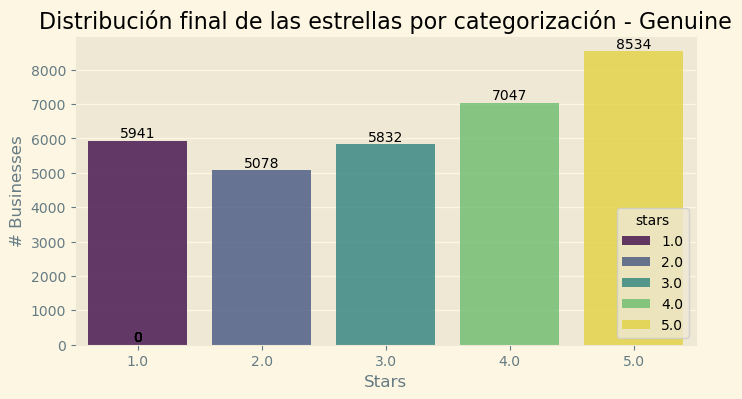

In [47]:
x=df_final_pl.filter(pl.col('classification') == 'Genuine')['stars'].value_counts().sort('count', descending=True)
plt.figure(figsize=(8,4))
ax = sns.barplot(x='stars', y='count',data=x, alpha=0.8,hue='stars',palette='viridis')
plt.title("Distribución final de las estrellas por categorización - Genuine")
plt.ylabel('# Businesses', fontsize=12)
plt.xlabel('Stars', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',           # Texto a mostrar (la altura de la barra como entero)
                (p.get_x() + p.get_width() / 2., p.get_height()), # Posición (x, y) para el texto
                ha='center',                       # Alineación horizontal
                va='center',                       # Alineación vertical
                xytext=(0, 5),                    # Desplazamiento del texto (en puntos): 0 horizontal, 5 vertical (encima de la barra)
                textcoords='offset points',        # Usar coordenadas de desplazamiento
                fontsize=10)                       # Tamaño de la fuente para la anotación


plt.show()

In [69]:
for stars in range(1, 6):
    print(f'Reseña genuine de {stars} estrellas de ejemplo: \n {df_final_pl.
        filter(pl.col('stars') == stars).
        filter(pl.col('classification') == 'Genuine')['text'][3]} \n')

Reseña genuine de 1 estrellas de ejemplo: 
 Great place to go-if you don't mind people banging lines of cocaine off of the toilet. 

Reseña genuine de 2 estrellas de ejemplo: 
 I think their pizza is a bit bland, not really my cup of tea. 

Reseña genuine de 3 estrellas de ejemplo: 
 Decent service, they will take your old hangers to recycle them, decent prices.

Much more to say about a dry-cleaner?  Nah. 

Reseña genuine de 4 estrellas de ejemplo: 
 very friendly place, the drinks are delicious and the lines are never too unbearable, especially in the morning. I prefer over the starbucks. 

Reseña genuine de 5 estrellas de ejemplo: 
 Yum! Nice atmosphere, friendly service and the best marinara sauce EVER! :) Will definitely be back! 



A continuación, veremos la distribución de las reseñas Fake

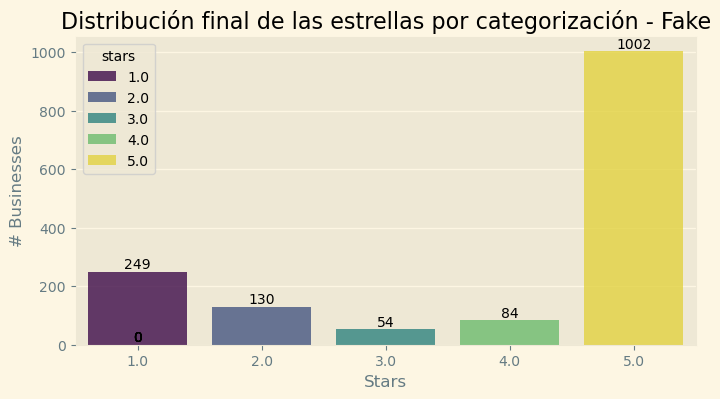

In [46]:
x=df_final_pl.filter(pl.col('classification') == 'Fake')['stars'].value_counts().sort('count', descending=True)
plt.figure(figsize=(8,4))
ax= sns.barplot(x='stars', y='count',data=x, alpha=0.8,hue='stars',palette='viridis')
plt.title("Distribución final de las estrellas por categorización - Fake")
plt.ylabel('# Businesses', fontsize=12)
plt.xlabel('Stars', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',           # Texto a mostrar (la altura de la barra como entero)
                (p.get_x() + p.get_width() / 2., p.get_height()), # Posición (x, y) para el texto
                ha='center',                       # Alineación horizontal
                va='center',                       # Alineación vertical
                xytext=(0, 5),                    # Desplazamiento del texto (en puntos): 0 horizontal, 5 vertical (encima de la barra)
                textcoords='offset points',        # Usar coordenadas de desplazamiento
                fontsize=10)                       # Tamaño de la fuente para la anotación


plt.show()

In [68]:
for stars in range(1, 6):
    print(f'Reseña fake de {stars} estrellas de ejemplo: \n {df_final_pl.
        filter(pl.col('stars') == stars).
        filter(pl.col('classification') == 'Fake')['text'][3]} \n')

Reseña fake de 1 estrellas de ejemplo: 
 See the updated review. 

Reseña fake de 2 estrellas de ejemplo: 
 Items are generally served out of a deli case and are reasonably priced at only a billion dollars a pound. 

Reseña fake de 3 estrellas de ejemplo: 
 Ordered a small plain pizza from the slice app for a decent price. First bite, was like eating mozzarella stick. The pizza was loaded with too much cheese 

Reseña fake de 4 estrellas de ejemplo: 
 Alas, this restaurant has gone the way of too many. Ciao. 

Reseña fake de 5 estrellas de ejemplo: 
 The best fries!! Day or night! Open late night too! Good for the soul man! 



# 3. Introduciremos las reseñas y sus metadatos seleccionados en la base de datos vectorial (Qdrant)